# Tutorial: Training a KNN Gait Classifier

This tutorial demonstrates how to train a K-Nearest Neighbors (KNN) classifier for gait condition classification using the AlexPose system.

## Learning Objectives

1. Extract gait features from video sequences
2. Create feature vectors for classification
3. Train a KNN classifier
4. Evaluate classifier performance
5. Use the classifier for predictions

## Prerequisites

- GAVD dataset CSV files organized by condition
- Downloaded YouTube videos in `data/youtube/`
- AlexPose environment activated

## 1. Setup and Imports

**IMPORTANT**: Run this cell first to suppress MediaPipe/TensorFlow logs.

In [ ]:
# CRITICAL: This must be the FIRST cell executed
# It configures the environment to suppress C++ logs from MediaPipe/TensorFlow

import sys
from pathlib import Path

# Add project root to path
project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

# Setup notebook environment (suppresses logs)
from ambient.utils.notebook_setup import setup_notebook
setup_notebook(verbose=True)

In [ ]:
# Configure matplotlib
import matplotlib
matplotlib.use('module://matplotlib_inline.backend_inline')
import matplotlib.pyplot as plt

# Enable interactive mode
plt.ion()

print(f"Matplotlib backend: {matplotlib.get_backend()}")

In [ ]:
# Standard library imports
import os
import string
import contextlib
import pandas as pd
import seaborn as sns
import numpy as np
from collections import defaultdict

# Setup paths
video_base_path = project_root / "data" / "youtube"
data_root = project_root / "experiments" / "exp3" / "data"

print(f"Project root: {project_root}")
print(f"Data root: {data_root}")
print(f"Video path: {video_base_path}")

In [3]:
@contextlib.contextmanager
def suppress_stderr_fd():
    """Suppress stderr at file descriptor level."""
    stderr_fd = sys.stderr.fileno()
    with open(os.devnull, 'w') as devnull:
        old_stderr = os.dup(stderr_fd)
        os.dup2(devnull.fileno(), stderr_fd)
        try:
            yield
        finally:
            os.dup2(old_stderr, stderr_fd)
            os.close(old_stderr)

# Import with suppression
with suppress_stderr_fd():
    from ambient.gavd import GAVDDataLoader
    from ambient.pose.keypoint_extractor import SequenceKeypointExtractor
    from ambient.pose.joint_angles import get_joint_angles

from ambient.classification.knn_classifier import (
    KNNGaitClassifier,
    KNNClassifierConfig,
    GaitFeatureVector
)

print("✓ Imports successful")

✓ Imports successful


## 2. Explore Available Data

Let's see what condition data we have available.

In [4]:
# Get condition directories
condition_paths = [
    p for p in data_root.iterdir() 
    if p.is_dir() and p.name[0] in string.ascii_letters
]

print(f"Found {len(condition_paths)} conditions:\n")
for path in sorted(condition_paths):
    csv_files = list(path.glob("*.csv"))
    print(f"  {path.name:15s}: {len(csv_files)} CSV files")

Found 4 conditions:

  antalgic       : 2 CSV files
  normal         : 2 CSV files
  parkinsons     : 2 CSV files
  stroke         : 2 CSV files


## 3. Extract Features from One Sample

Let's walk through the feature extraction process for a single sample.

In [5]:
# Load one sample
sample_condition = condition_paths[0]
sample_csv = list(sample_condition.glob("*.csv"))[0]

print(f"Sample condition: {sample_condition.name}")
print(f"Sample CSV: {sample_csv.name}")

# Load GAVD data
gavd_loader = GAVDDataLoader()
df = gavd_loader.load_gavd_data(str(sample_csv))
sequences = gavd_loader.organize_by_sequence(df)

print(f"\nFound {len(sequences)} sequences in this CSV")
print(f"Sequence IDs: {list(sequences.keys())}")

Sample condition: antalgic
Sample CSV: cljawh4c7000m3n6lkz9es9bl.csv

Found 1 sequences in this CSV
Sequence IDs: ['cljawh4c7000m3n6lkz9es9bl']


In [6]:
# Extract keypoints from first sequence
seq_id = list(sequences.keys())[0]
sequence_df = sequences[seq_id]

print(f"Processing sequence: {seq_id}")
print(f"Number of frames: {len(sequence_df)}")

extractor = SequenceKeypointExtractor()
keypoints_array = extractor.extract_from_sequence(
    sequence_df,
    video_base_path=video_base_path,
    verbose=True
)

print(f"\n✓ Extracted {len(keypoints_array)} keypoint frames")

I0000 00:00:1768870648.937722 6356642 gl_context.cc:407] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M2 Max
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1768870648.986560 6356643 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1768870648.995382 6356653 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
2026-01-19 16:57:28.996 | INFO     | ambient.pose.keypoint_extractor:extract_from_sequence:595 - Processing sequence: cljawh4c7000m3n6lkz9es9bl
2026-01-19 16:57:28.996 | INFO     | ambient.pose.keypoint_extractor:extract_from_sequence:596 - Number of frames: 145


Processing sequence: cljawh4c7000m3n6lkz9es9bl
Number of frames: 145
	frame 1470 (1/145)


W0000 00:00:1768870649.239198 6356646 landmark_projection_calculator.cc:81] Using NORM_RECT without IMAGE_DIMENSIONS is only supported for the square ROI. Provide IMAGE_DIMENSIONS or use PROJECTION_MATRIX.


	frame 1480 (11/145)
	frame 1490 (21/145)
	frame 1500 (31/145)
	frame 1510 (41/145)
	frame 1520 (51/145)
	frame 1530 (61/145)
	frame 1540 (71/145)
	frame 1550 (81/145)
	frame 1560 (91/145)
	frame 1570 (101/145)
	frame 1580 (111/145)
	frame 1590 (121/145)
	frame 1600 (131/145)
	frame 1610 (141/145)


2026-01-19 16:58:04.297 | INFO     | ambient.pose.keypoint_extractor:extract_from_sequence:635 - Sequence processing complete



✓ Extracted 145 keypoint frames


In [7]:
# Calculate joint angles
joint_angles = get_joint_angles(
    keypoints_array=keypoints_array,
    keypoint_format="BLAZEPOSE_33",
    fps=30.0,
    confidence_threshold=0.3,
    sequence_id=seq_id
)

print(f"Computed joint angles for {len(joint_angles.frames)} frames")
print(f"\nAvailable joints: {list(joint_angles.frames[0].angles.keys())}")

Computed joint angles for 145 frames

Available joints: ['left_hip', 'left_knee', 'right_hip', 'right_knee', 'left_ankle', 'right_ankle']



Visualizing joint angles...
Number of frames with joint angles: 145


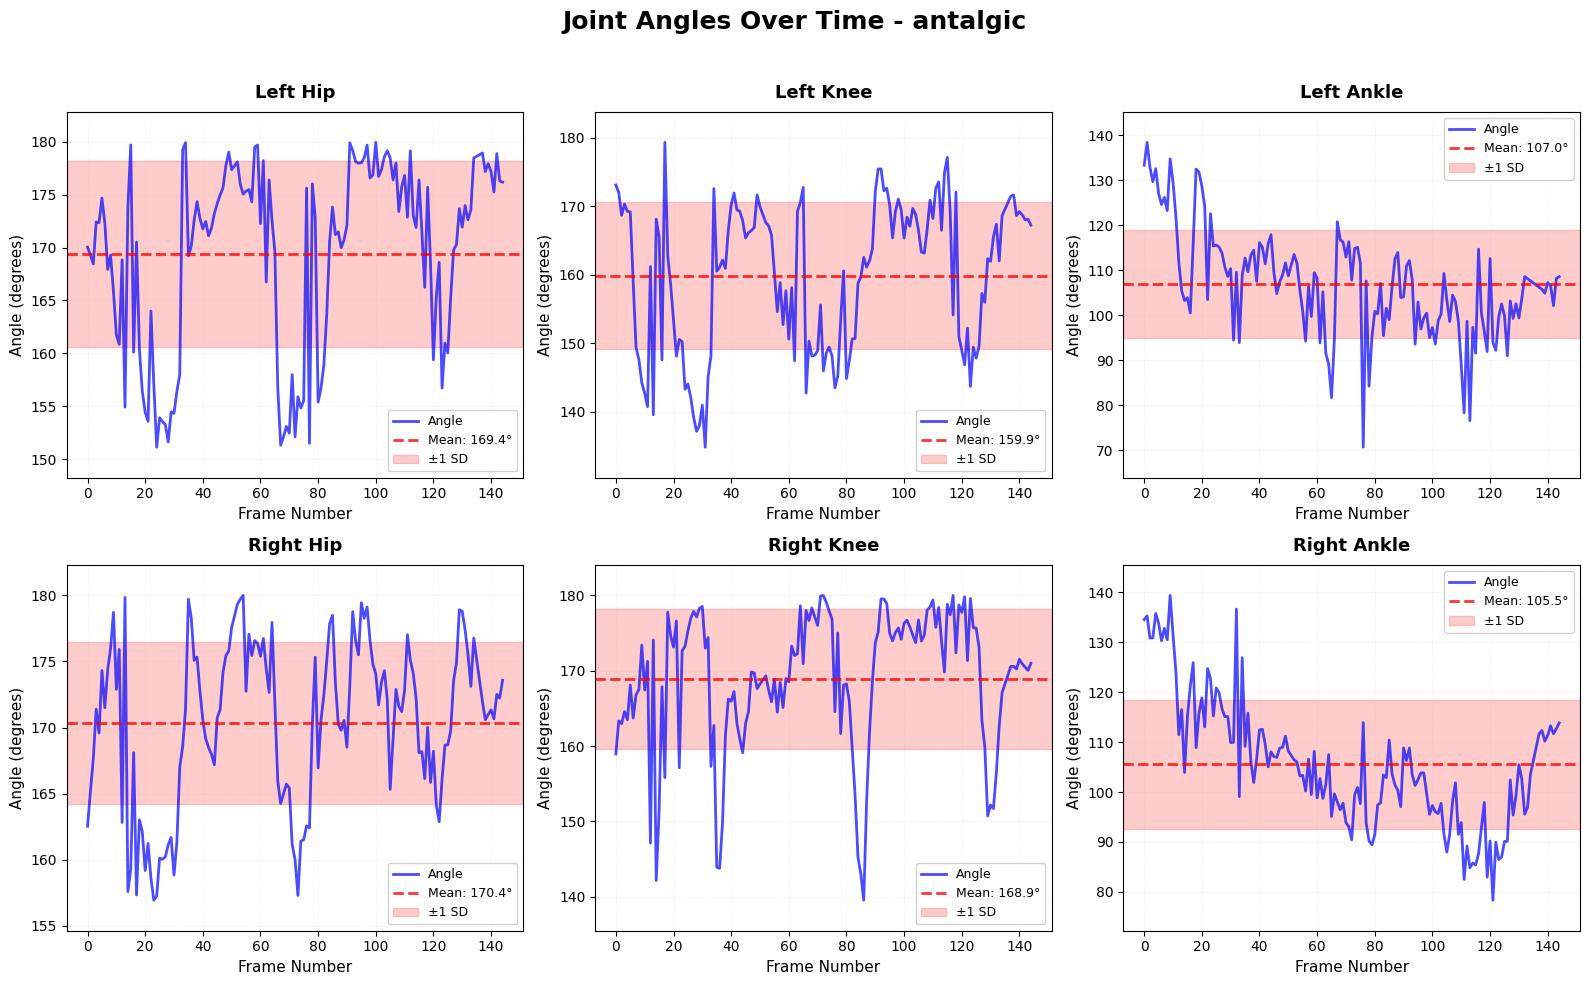


Joint Angle Statistics
Joint               Mean      Std      Min      Max    Range
----------------------------------------------------------------------
left_hip           169.4°     8.8°   151.1°   179.9°    28.8°
left_knee          159.9°    10.8°   134.8°   179.3°    44.5°
left_ankle         107.0°    12.0°    70.7°   138.4°    67.7°
right_hip          170.4°     6.1°   156.9°   180.0°    23.0°
right_knee         168.9°     9.3°   139.6°   180.0°    40.4°
right_ankle        105.5°    12.9°    78.3°   139.4°    61.1°



In [11]:
# Visualize joint angles over time
print(f"\nVisualizing joint angles...")
print(f"Number of frames with joint angles: {len(joint_angles.frames)}")

if len(joint_angles.frames) > 0 and len(joint_angles.frames[0].angles) > 0:
    joints = ['left_hip', 'left_knee', 'left_ankle', 'right_hip', 'right_knee', 'right_ankle']
    
    # Create the figure
    fig, axes = plt.subplots(2, 3, figsize=(16, 10))
    fig.suptitle(f"Joint Angles Over Time - {sample_condition.name}", fontsize=18, fontweight='bold')
    
    for idx, joint_name in enumerate(joints):
        row = idx // 3
        col = idx % 3
        ax = axes[row, col]
        
        try:
            # Get angle data
            angles = joint_angles.get_joint_angle_series(joint_name)
            stats = joint_angles.get_statistics(joint_name)
            
            # Check if we have valid data
            if stats['valid_count'] > 0 and not np.isnan(stats['mean']):
                # Filter out NaN values
                valid_mask = ~np.isnan(angles)
                valid_frames = np.where(valid_mask)[0]
                valid_angles = angles[valid_mask]
                
                if len(valid_angles) > 0:
                    # Plot the angle series
                    ax.plot(valid_frames, valid_angles, 'b-', linewidth=2, alpha=0.7, label='Angle')
                    
                    # Add mean line
                    ax.axhline(y=stats['mean'], color='red', linestyle='--', 
                              linewidth=2, alpha=0.8, label=f"Mean: {stats['mean']:.1f}°")
                    
                    # Add shaded region for std
                    ax.axhspan(stats['mean'] - stats['std'], stats['mean'] + stats['std'], 
                              alpha=0.2, color='red', label=f"±1 SD")
                    
                    # Formatting
                    ax.set_title(joint_name.replace('_', ' ').title(), 
                                fontsize=13, fontweight='bold', pad=10)
                    ax.set_xlabel('Frame Number', fontsize=11)
                    ax.set_ylabel('Angle (degrees)', fontsize=11)
                    ax.legend(loc='best', fontsize=9, framealpha=0.9)
                    ax.grid(True, alpha=0.3, linestyle=':', linewidth=0.5)
                    
                    # Set reasonable y-axis limits
                    y_margin = (stats['max'] - stats['min']) * 0.1
                    ax.set_ylim(stats['min'] - y_margin, stats['max'] + y_margin)
                else:
                    ax.text(0.5, 0.5, 'No valid angle data', 
                           ha='center', va='center', transform=ax.transAxes, 
                           fontsize=12, color='gray')
                    ax.set_title(joint_name.replace('_', ' ').title())
            else:
                ax.text(0.5, 0.5, 'Insufficient data', 
                       ha='center', va='center', transform=ax.transAxes, 
                       fontsize=12, color='gray')
                ax.set_title(joint_name.replace('_', ' ').title())
                
        except Exception as e:
            ax.text(0.5, 0.5, f'Error: {str(e)[:40]}', 
                   ha='center', va='center', transform=ax.transAxes, 
                   fontsize=10, color='red', wrap=True)
            ax.set_title(joint_name.replace('_', ' ').title())
            print(f"Error plotting {joint_name}: {e}")
    
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()
    
    # Print statistics table
    print("\n" + "="*70)
    print("Joint Angle Statistics")
    print("="*70)
    print(f"{'Joint':<15} {'Mean':>8} {'Std':>8} {'Min':>8} {'Max':>8} {'Range':>8}")
    print("-"*70)
    
    for joint_name in joints:
        try:
            stats = joint_angles.get_statistics(joint_name)
            if stats['valid_count'] > 0:
                print(f"{joint_name:<15} {stats['mean']:>8.1f}° {stats['std']:>7.1f}° "
                      f"{stats['min']:>7.1f}° {stats['max']:>7.1f}° {stats['range']:>7.1f}°")
            else:
                print(f"{joint_name:<15} {'No data':>8}")
        except Exception as e:
            print(f"{joint_name:<15} Error: {e}")
    print("="*70 + "\n")
    
else:
    print("\n⚠️  WARNING: No joint angles computed!")
    print(f"   Total frames: {len(joint_angles.frames)}")
    if len(joint_angles.frames) > 0:
        print(f"   Angles in first frame: {len(joint_angles.frames[0].angles)}")
        print(f"   Available joints: {list(joint_angles.frames[0].angles.keys())}")
    print("   Check if keypoints were extracted successfully.\n")

In [9]:
# Create feature vector
feature_vector = GaitFeatureVector.from_joint_angles(
    joint_angles,
    sample_id=seq_id,
    condition_label=sample_condition.name
)

print("Feature Vector:")
print(f"  Sample ID: {feature_vector.sample_id}")
print(f"  Condition: {feature_vector.condition_label}")
print(f"\nFeatures:")
for name in GaitFeatureVector.get_feature_names():
    value = getattr(feature_vector, name)
    print(f"  {name:20s}: {value:7.2f}")

Feature Vector:
  Sample ID: cljawh4c7000m3n6lkz9es9bl
  Condition: antalgic

Features:
  left_hip_mean       :  169.39
  left_knee_mean      :  159.89
  left_ankle_mean     :  107.00
  right_hip_mean      :  170.35
  right_knee_mean     :  168.86
  right_ankle_mean    :  105.54
  hip_asymmetry       :    0.96
  knee_asymmetry      :    8.97
  ankle_asymmetry     :    1.46
  left_hip_range      :   28.77
  left_knee_range     :   44.50
  right_hip_range     :   23.05
  right_knee_range    :   40.42


## 4. Extract Features from All Samples

Now let's extract features from all available samples.

In [12]:
def extract_all_features(condition_paths, video_base_path):
    """Extract features from all condition directories."""
    all_features = []
    condition_counts = defaultdict(int)
    gavd_loader = GAVDDataLoader()
    
    for condition_path in condition_paths:
        condition_name = condition_path.name
        print(f"\nProcessing: {condition_name}")
        
        for csv_path in condition_path.glob("*.csv"):
            try:
                df = gavd_loader.load_gavd_data(str(csv_path))
                sequences = gavd_loader.organize_by_sequence(df)
                
                for seq_id in sequences:
                    try:
                        sequence_df = sequences[seq_id]
                        
                        # Extract keypoints
                        extractor = SequenceKeypointExtractor()
                        keypoints_array = extractor.extract_from_sequence(
                            sequence_df,
                            video_base_path=video_base_path,
                            verbose=False
                        )
                        
                        if not keypoints_array:
                            continue
                        
                        # Calculate joint angles
                        joint_angles = get_joint_angles(
                            keypoints_array=keypoints_array,
                            keypoint_format="BLAZEPOSE_33",
                            fps=30.0,
                            confidence_threshold=0.3,
                            sequence_id=seq_id
                        )
                        
                        if len(joint_angles.frames) == 0:
                            continue
                        
                        # Create feature vector
                        feature_vector = GaitFeatureVector.from_joint_angles(
                            joint_angles,
                            sample_id=seq_id,
                            condition_label=condition_name
                        )
                        
                        all_features.append(feature_vector)
                        condition_counts[condition_name] += 1
                        print(f"  ✓ {seq_id}")
                    
                    except Exception as e:
                        print(f"  ✗ {seq_id}: {e}")
            
            except Exception as e:
                print(f"  Error processing {csv_path.name}: {e}")
    
    return all_features, dict(condition_counts)

# Extract all features
all_features, condition_counts = extract_all_features(condition_paths, video_base_path)

print(f"\n{'='*60}")
print(f"Total features extracted: {len(all_features)}")
print(f"\nCondition distribution:")
for condition, count in sorted(condition_counts.items()):
    print(f"  {condition:15s}: {count:3d} samples")


Processing: antalgic


I0000 00:00:1768870802.664121 6376785 gl_context.cc:407] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M2 Max
W0000 00:00:1768870802.714484 6376787 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1768870802.722961 6376797 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


  ✓ cljawh4c7000m3n6lkz9es9bl


I0000 00:00:1768870845.289665 6388591 gl_context.cc:407] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M2 Max
W0000 00:00:1768870845.340131 6388593 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1768870845.348512 6388602 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


  ✓ cljawf4e4000h3n6lri4oz9uy

Processing: stroke
  ✓ cljr5iki0000j3n6lwi8z5nh6


...

  ✓ cljnz6vg1000s3n6lxxknbe72


I0000 00:00:1768870981.495682 6419341 gl_context.cc:407] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M2 Max
W0000 00:00:1768870981.546528 6419343 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1768870981.556106 6419345 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


  ✓ cljnz5sb1000o3n6lntosswwz

Processing: normal


I0000 00:00:1768870991.913741 6423187 gl_context.cc:407] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M2 Max
W0000 00:00:1768870991.965099 6423190 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1768870991.974420 6423190 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


  ✓ cljo2yqzp001i3n6lg75p7wtq
  ✓ cljo2zn41001m3n6lhbvww48i

Total features extracted: 8

Condition distribution:
  antalgic       :   2 samples
  normal         :   2 samples
  parkinsons     :   2 samples
  stroke         :   2 samples


## 5. Visualize Feature Distributions

Let's visualize how features differ across conditions.

In [14]:
# Convert to DataFrame for visualization
feature_data = []
for fv in all_features:
    row = {name: getattr(fv, name) for name in GaitFeatureVector.get_feature_names()}
    row['condition'] = fv.condition_label
    feature_data.append(row)

df_features = pd.DataFrame(feature_data)
print(df_features.head())

   left_hip_mean  left_knee_mean  left_ankle_mean  right_hip_mean  \
0     169.391786      159.886273       107.000716      170.352351   
1     166.777360      158.492825       102.346447      171.985720   
2      76.979710       72.227276       126.784871       90.234718   
3     175.911296      173.881222       168.583360      177.255321   
4     173.930344      175.567509       124.399410      173.090896   

   right_knee_mean  right_ankle_mean  hip_asymmetry  knee_asymmetry  \
0       168.857995        105.542551       0.960565        8.971722   
1       167.716325        102.926208       5.208360        9.223500   
2        65.059949        140.385344      13.255008        7.167327   
3       172.593322        154.329939       1.344026        1.287901   
4       174.384067        141.633668       0.839448        1.183442   

   ankle_asymmetry  left_hip_range  left_knee_range  right_hip_range  \
0         1.458165       28.773629        44.497695        23.046915   
1         0.57

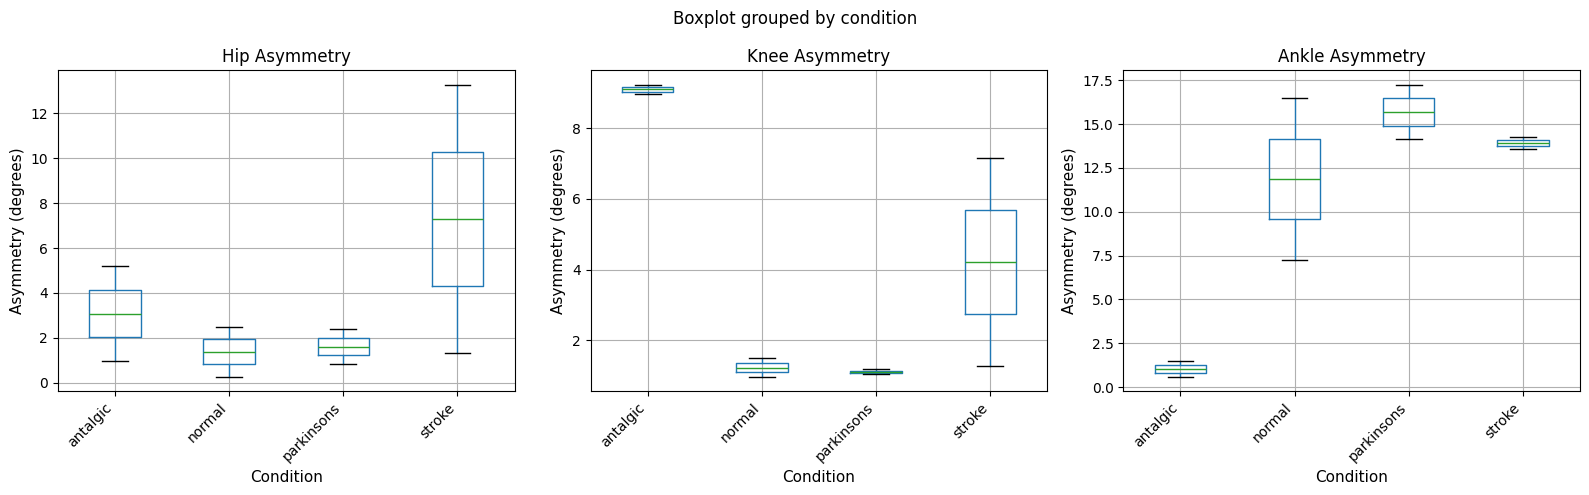

In [15]:
# Plot asymmetry features by condition
if len(all_features) > 0:
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    fig.suptitle("Asymmetry Features by Condition", fontsize=16, fontweight='bold')
    
    asymmetry_features = ['hip_asymmetry', 'knee_asymmetry', 'ankle_asymmetry']
    
    for idx, feature in enumerate(asymmetry_features):
        ax = axes[idx]
        df_features.boxplot(column=feature, by='condition', ax=ax)
        ax.set_title(feature.replace('_', ' ').title(), fontsize=12)
        ax.set_xlabel('Condition', fontsize=11)
        ax.set_ylabel('Asymmetry (degrees)', fontsize=11)
        plt.sca(ax)
        plt.xticks(rotation=45, ha='right')
    
    plt.tight_layout()
    plt.show()
else:
    print("No features to visualize")

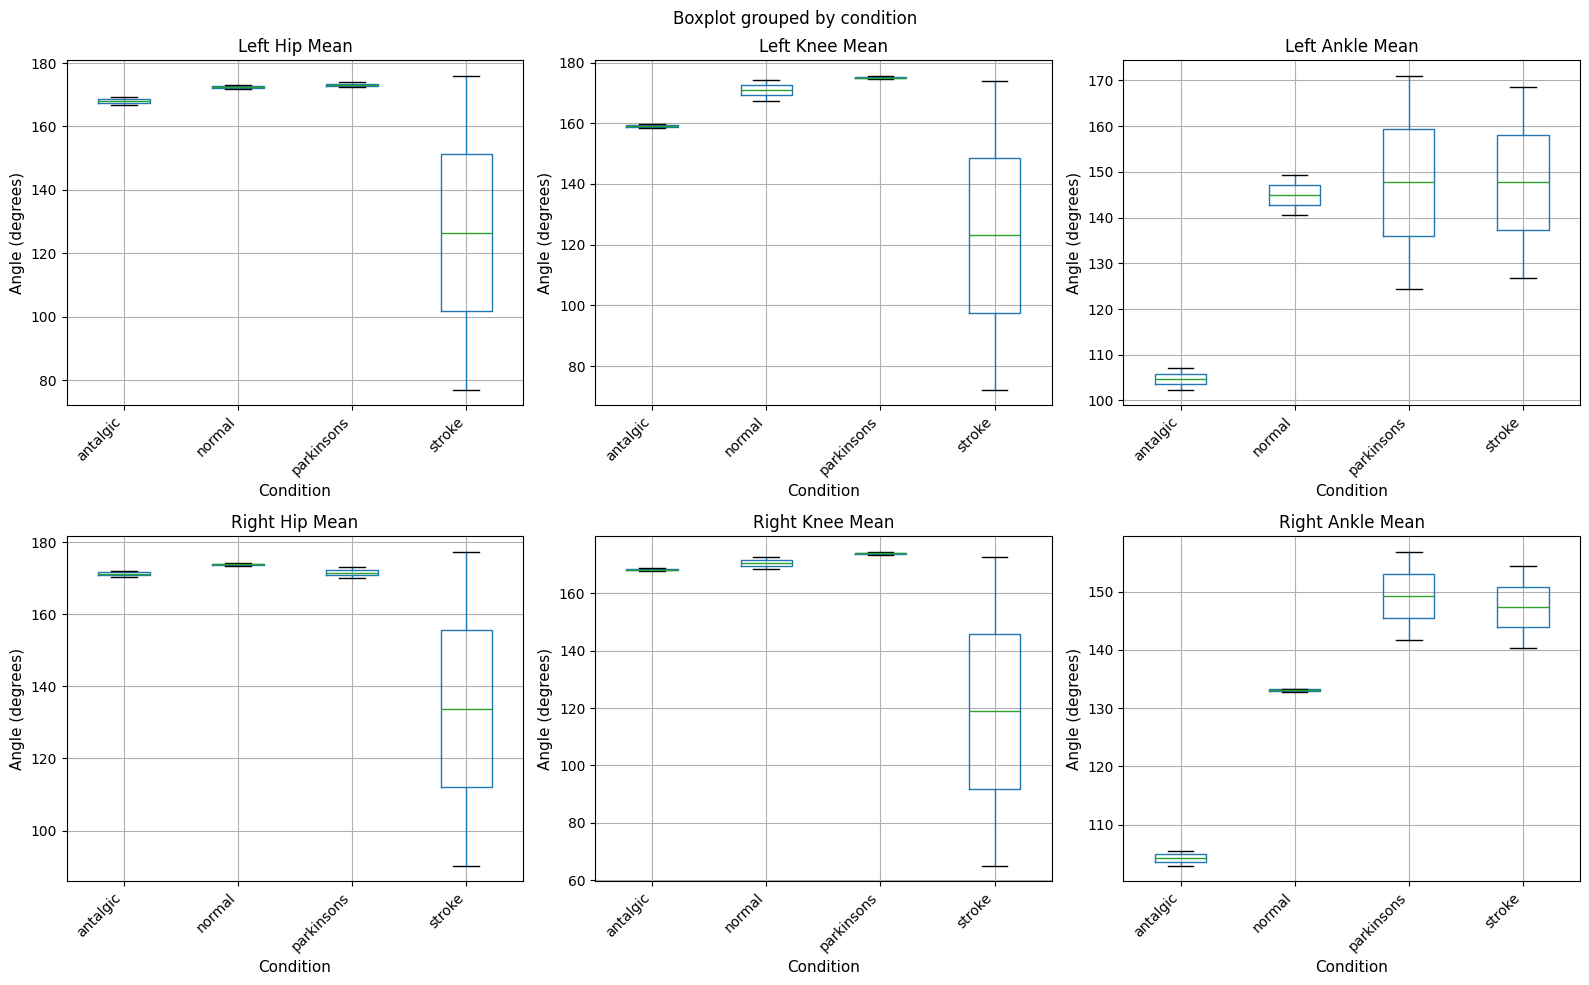

In [16]:
# Plot mean joint angles by condition
if len(all_features) > 0:
    fig, axes = plt.subplots(2, 3, figsize=(16, 10))
    fig.suptitle("Mean Joint Angles by Condition", fontsize=16, fontweight='bold')
    
    angle_features = [
        'left_hip_mean', 'left_knee_mean', 'left_ankle_mean',
        'right_hip_mean', 'right_knee_mean', 'right_ankle_mean'
    ]
    
    for idx, feature in enumerate(angle_features):
        ax = axes[idx // 3, idx % 3]
        df_features.boxplot(column=feature, by='condition', ax=ax)
        ax.set_title(feature.replace('_', ' ').title(), fontsize=12)
        ax.set_xlabel('Condition', fontsize=11)
        ax.set_ylabel('Angle (degrees)', fontsize=11)
        plt.sca(ax)
        plt.xticks(rotation=45, ha='right')
    
    plt.tight_layout()
    plt.show()
else:
    print("No features to visualize")

## 6. Train KNN Classifier

Now let's train a KNN classifier on our extracted features.

In [17]:
# Split into train/test (80/20)
np.random.seed(42)
indices = np.random.permutation(len(all_features))
split_idx = int(0.8 * len(all_features))

train_indices = indices[:split_idx]
test_indices = indices[split_idx:]

train_features = [all_features[i] for i in train_indices]
test_features = [all_features[i] for i in test_indices]

print(f"Training samples: {len(train_features)}")
print(f"Test samples: {len(test_features)}")

Training samples: 6
Test samples: 2


In [ ]:
# Configure and train classifier
config = KNNClassifierConfig(
    n_neighbors=5,
    weights="distance",
    metric="euclidean",
    normalize_features=True
)

classifier = KNNGaitClassifier(config=config)
metrics = classifier.train(train_features, validate=True)

print("\nTraining Results:")
print(f"  Training Accuracy: {metrics['train_accuracy']:.3f}")
if 'cv_mean_accuracy' in metrics:
    print(f"  CV Accuracy: {metrics['cv_mean_accuracy']:.3f} ± {metrics['cv_std_accuracy']:.3f}")
print(f"  Classes: {metrics['classes']}")

## 7. Evaluate Classifier

Let's evaluate the classifier on our test set.

In [ ]:
# Evaluate on test set
eval_metrics = classifier.evaluate(test_features)

print(f"Test Accuracy: {eval_metrics['accuracy']:.3f}")
print(f"\nClassification Report:")
report = eval_metrics['classification_report']
for class_name in eval_metrics['classes']:
    if class_name in report:
        cm = report[class_name]
        print(f"\n{class_name}:")
        print(f"  Precision: {cm['precision']:.3f}")
        print(f"  Recall: {cm['recall']:.3f}")
        print(f"  F1-Score: {cm['f1-score']:.3f}")

In [ ]:
# Plot confusion matrix
if len(test_features) > 0:
    conf_matrix = np.array(eval_metrics['confusion_matrix'])
    classes = eval_metrics['classes']
    
    fig = plt.figure(figsize=(10, 8))
    sns.heatmap(
        conf_matrix,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=classes,
        yticklabels=classes,
        cbar_kws={'label': 'Count'}
    )
    plt.title('Confusion Matrix', fontsize=16, fontweight='bold', pad=15)
    plt.ylabel('True Label', fontsize=12)
    plt.xlabel('Predicted Label', fontsize=12)
    plt.tight_layout()
    plt.show()
else:
    print("No test data to visualize")

## 8. Make Predictions

Let's use the trained classifier to make predictions on new samples.

In [ ]:
# Predict on a test sample
test_sample = test_features[0]

result = classifier.classify_gait(test_sample)

print(f"Sample ID: {test_sample.sample_id}")
print(f"True Condition: {test_sample.condition_label}")
print(f"\nPredicted Condition: {result['predicted_condition']}")
print(f"Confidence: {result['confidence']:.2%}")
print(f"\nProbability Distribution:")
for condition, prob in sorted(result['probabilities'].items(), key=lambda x: x[1], reverse=True):
    bar = '█' * int(prob * 30)
    print(f"  {condition:15s}: {prob:.2%} {bar}")

In [ ]:
# Get explanation
explanation = classifier.explain_classification(result)
print(explanation)

## 9. Save Trained Classifier

Save the classifier for later use.

In [ ]:
# Save classifier
model_dir = project_root / "experiments" / "exp2" / "models"
model_dir.mkdir(parents=True, exist_ok=True)

model_path = model_dir / "knn_classifier_tutorial.pkl"
classifier.save(model_path)

print(f"✓ Classifier saved to: {model_path}")

## 10. Load and Use Saved Classifier

Demonstrate loading a saved classifier.

In [ ]:
# Load classifier
loaded_classifier = KNNGaitClassifier.load(model_path)

print(f"✓ Classifier loaded from: {model_path}")
print(f"  Classes: {loaded_classifier.classes_}")
print(f"  K: {loaded_classifier.config.n_neighbors}")

# Test loaded classifier
result = loaded_classifier.classify_gait(test_features[1])
print(f"\nTest prediction: {result['predicted_condition']} (confidence: {result['confidence']:.2%})")

## Summary

In this tutorial, you learned:

1. ✓ How to extract gait features from video sequences
2. ✓ How to create feature vectors for classification
3. ✓ How to train a KNN classifier
4. ✓ How to evaluate classifier performance
5. ✓ How to use the classifier for predictions
6. ✓ How to save and load trained classifiers

## Next Steps

- Experiment with different values of k
- Try different distance metrics
- Add more training data
- Compare with LLM-based classification
- Integrate into the web application

## Resources

- [KNN Classifier Documentation](../../docs/classifier/README.md)
- [API Reference](../../docs/classifier/README.md#api-reference)
- [Best Practices](../../docs/classifier/README.md#best-practices)